In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Makine': ['Carding', 'Cross-Lapper', 'Needle-Punch', 'Cutting', 'Packaging'],
    'Kapasite': [500, 450, 400, 380, 420],
    'Uretim': [430, 390, 310, 370, 400]
}

df = pd.DataFrame(data)
df['Kullanim_Orani'] = df['Uretim'] / df['Kapasite'] * 100

print(df)

Matplotlib is building the font cache; this may take a moment.


         Makine  Kapasite  Uretim  Kullanim_Orani
0       Carding       500     430       86.000000
1  Cross-Lapper       450     390       86.666667
2  Needle-Punch       400     310       77.500000
3       Cutting       380     370       97.368421
4     Packaging       420     400       95.238095


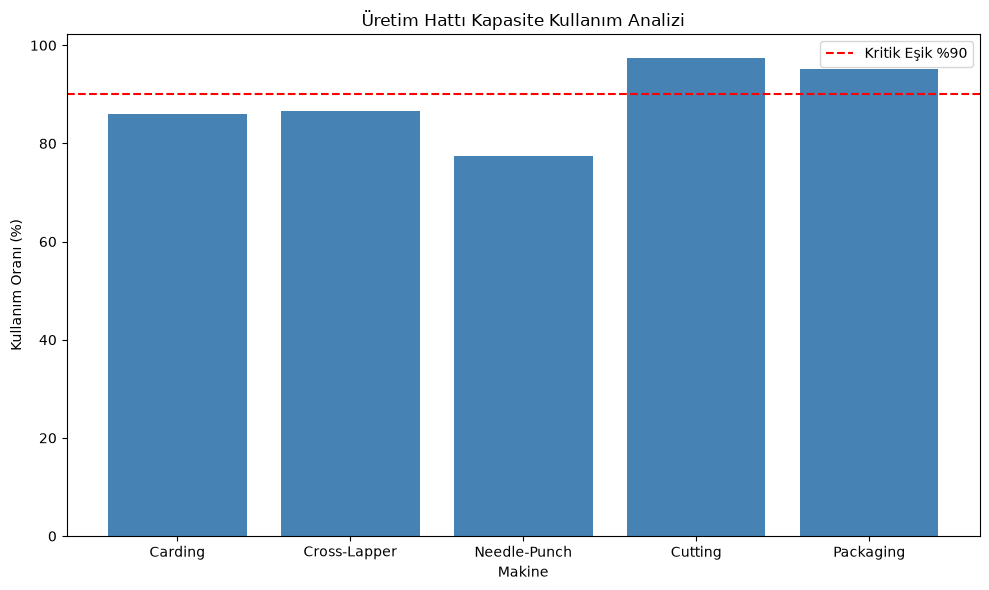

In [2]:
plt.figure(figsize=(10, 6))
plt.bar(df['Makine'], df['Kullanim_Orani'], color='steelblue')
plt.axhline(y=90, color='red', linestyle='--', label='Kritik Eşik %90')
plt.xlabel('Makine')
plt.ylabel('Kullanım Oranı (%)')
plt.title('Üretim Hattı Kapasite Kullanım Analizi')
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
darbogazlar = df[df['Kullanim_Orani'] > 90]
print("=== DARBOĞAZ MAKİNELER ===")
print(darbogazlar[['Makine', 'Kullanim_Orani']])

print("\n=== ÖNERİ ===")
for _, row in darbogazlar.iterrows():
    print(f"{row['Makine']} makinesi %{row['Kullanim_Orani']:.1f} dolulukta - kapasite artırımı gerekiyor.")

=== DARBOĞAZ MAKİNELER ===
      Makine  Kullanim_Orani
3    Cutting       97.368421
4  Packaging       95.238095

=== ÖNERİ ===
Cutting makinesi %97.4 dolulukta - kapasite artırımı gerekiyor.
Packaging makinesi %95.2 dolulukta - kapasite artırımı gerekiyor.


In [1]:
import numpy as np

# EOQ Parametreleri
talep = 10000      # yıllık talep (adet)
siparis_maliyeti = 500   # her siparişin sabit maliyeti (TL)
birim_maliyet = 50       # ürün birim maliyeti (TL)
tutma_orani = 0.20       # yıllık tutma maliyeti oranı

tutma_maliyeti = birim_maliyet * tutma_orani

# EOQ Formülü
eoq = np.sqrt((2 * talep * siparis_maliyeti) / tutma_maliyeti)

print(f"Yıllık Talep: {talep} adet")
print(f"Optimal Sipariş Miktarı (EOQ): {eoq:.0f} adet")
print(f"Yılda Kaç Kez Sipariş: {talep/eoq:.1f} kez")
print(f"Kaç Günde Bir Sipariş: {365/(talep/eoq):.0f} gün")

Yıllık Talep: 10000 adet
Optimal Sipariş Miktarı (EOQ): 1000 adet
Yılda Kaç Kez Sipariş: 10.0 kez
Kaç Günde Bir Sipariş: 36 gün


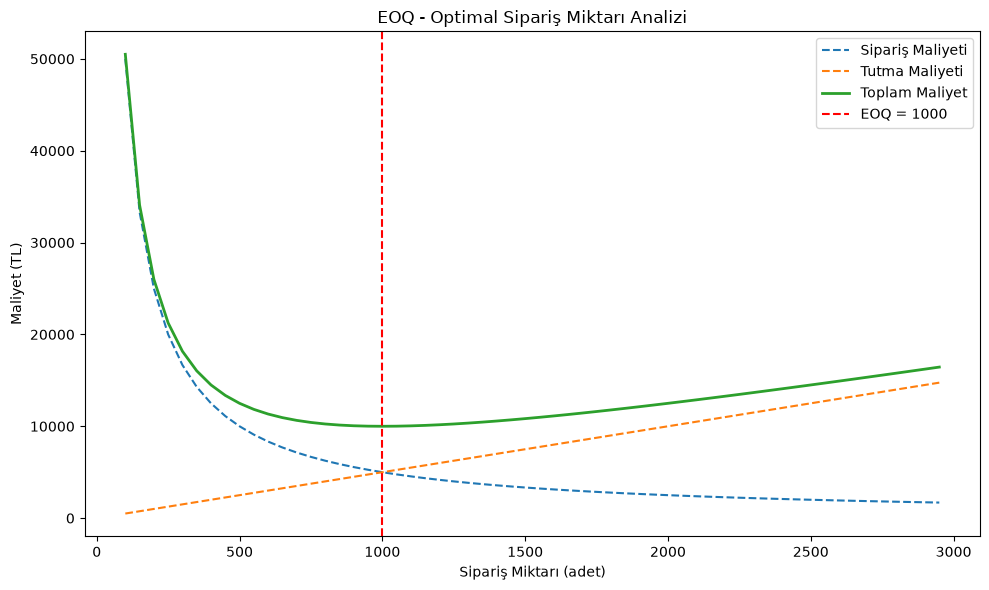

In [4]:
miktarlar = np.arange(100, 3000, 50)

siparis_toplam = (talep / miktarlar) * siparis_maliyeti
tutma_toplam = (miktarlar / 2) * tutma_maliyeti
toplam = siparis_toplam + tutma_toplam

plt.figure(figsize=(10, 6))
plt.plot(miktarlar, siparis_toplam, label='Sipariş Maliyeti', linestyle='--')
plt.plot(miktarlar, tutma_toplam, label='Tutma Maliyeti', linestyle='--')
plt.plot(miktarlar, toplam, label='Toplam Maliyet', linewidth=2)
plt.axvline(x=eoq, color='red', linestyle='--', label=f'EOQ = {eoq:.0f}')
plt.xlabel('Sipariş Miktarı (adet)')
plt.ylabel('Maliyet (TL)')
plt.title('EOQ - Optimal Sipariş Miktarı Analizi')
plt.legend()
plt.tight_layout()
plt.show()